# Import Required Libraries

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import adi

# Plotting Functions

In [24]:
def plot_scatter(signal):
    plt.figure(figsize=(3, 3))
    plt.scatter(signal.real, signal.imag, color='blue', alpha=0.5, s=30)
    plt.xlabel("Real Part")
    plt.ylabel("Imaginary Part")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

def plot_signal(signal, length, label_name, color_name):
    plt.figure(figsize=(15, 3))
    plt.plot(signal[:length], '.-', label = label_name, color = color_name)
    plt.grid(True)
    plt.legend()
    plt.show()

# Configure SDR and Receive

In [25]:
sample_rate = 10e6 # Hz
carrier_freq = 985e6 # Hz
num_samps = 500000 

sdr2 = adi.Pluto("ip:192.168.3.1")
sdr2.sample_rate = int(sample_rate)

sdr2.rx_lo = int(carrier_freq)
sdr2.rx_rf_bandwidth = int(sample_rate)
sdr2.rx_buffer_size = num_samps
sdr2.gain_control_mode_chan0 = 'slow_attack'
# sdr2.rx_hardwaregain_chan0 = 70 # dB


for j in range(5):
    _ = sdr2.rx()

rx_samples = sdr2.rx()
print('number of received signal samples:', len(rx_samples))

number of received signal samples: 500000


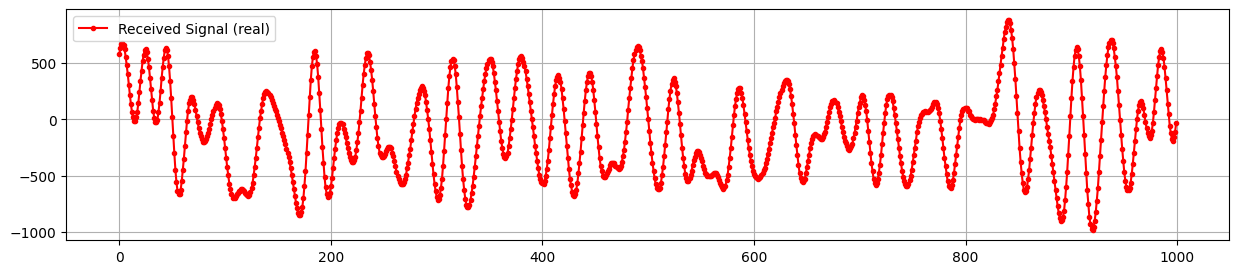

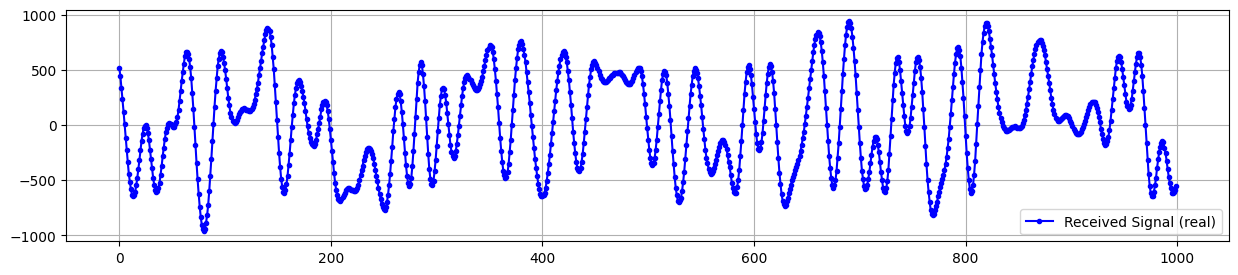

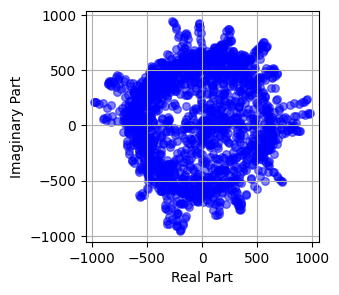

In [26]:
plot_signal(rx_samples.real, 1000, 'Received Signal (real)', 'red') 
plot_signal(rx_samples.imag, 1000, 'Received Signal (real)', 'blue')
plot_scatter(rx_samples[:2000])

# Matched Filtering

In [27]:
sps = 10
num_taps = 101
beta = 0.34
Ts = sps 
t = np.arange(num_taps) - (num_taps-1)//2
rc_pulse = np.sinc(t/Ts) * np.cos(np.pi*beta*t/Ts) / (1 - (2*beta*t/Ts)**2)
matched_filter =  rc_pulse
################################################################################
MF_op = np.convolve(rx_samples, matched_filter, mode='same')

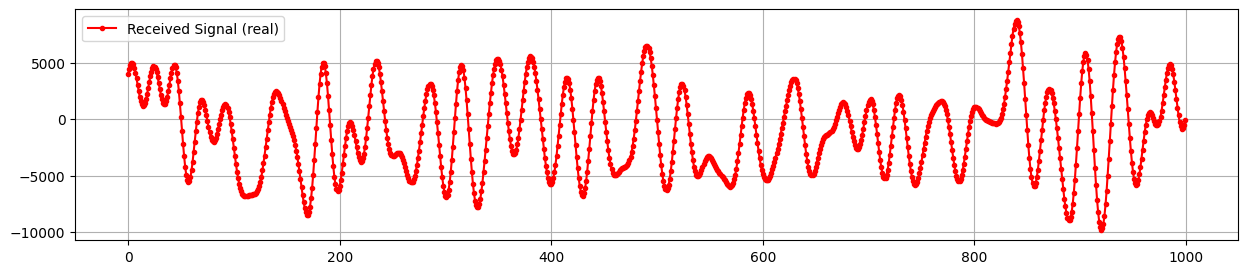

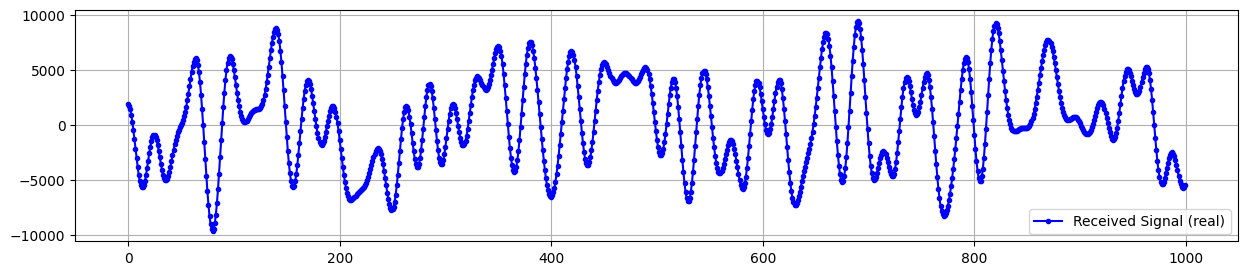

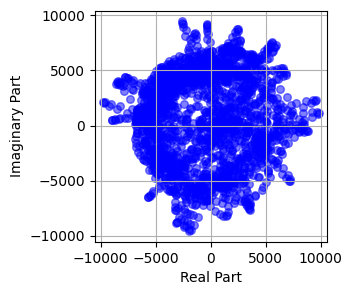

In [28]:
plot_signal(MF_op.real, 1000, 'Received Signal (real)', 'red') 
plot_signal(MF_op.imag, 1000, 'Received Signal (real)', 'blue')
plot_scatter(MF_op[:2000])

# Normalization 1

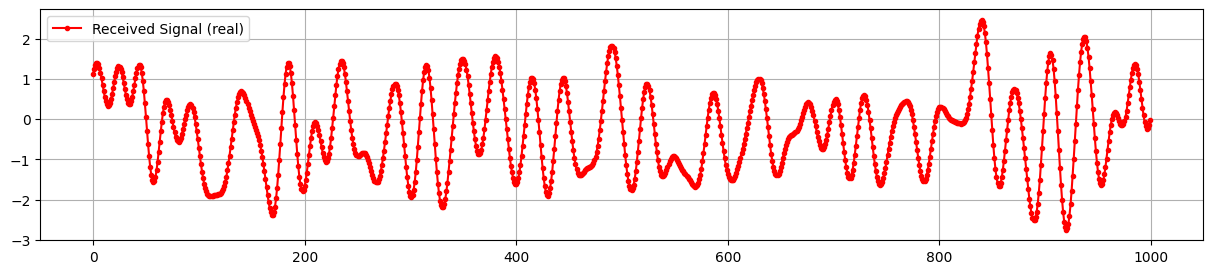

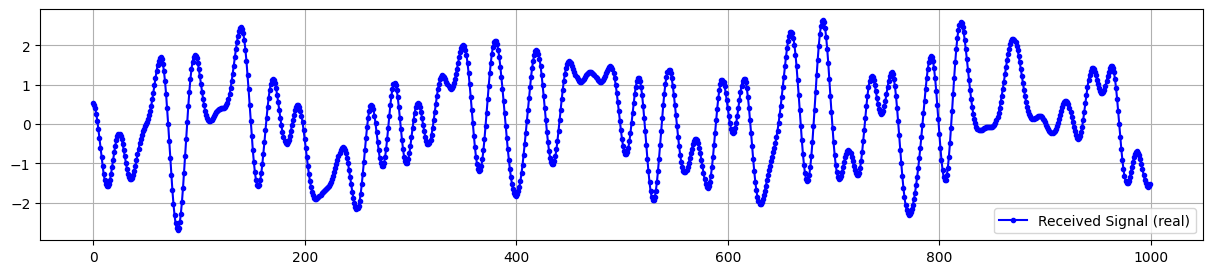

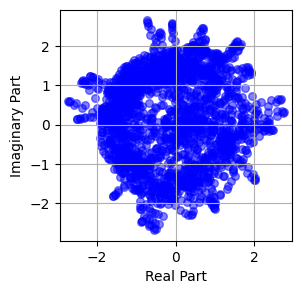

In [29]:
#updated code for normalization
max_allowed = 3
rx_max = np.max(np.abs(MF_op))
scale_coarse = max_allowed / rx_max
normalized_rx = MF_op * scale_coarse

plot_signal(normalized_rx.real, 1000, 'Received Signal (real)', 'red') 
plot_signal(normalized_rx.imag, 1000, 'Received Signal (real)', 'blue')
plot_scatter(normalized_rx[:2000])

# Coarse Frequency Synchronization

### FFT based Offset Estimation


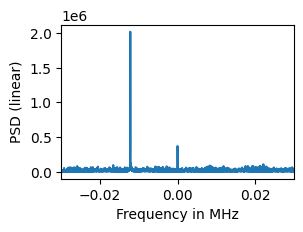

offset (Hz): -12190.0


In [30]:
squared_FO = normalized_rx**4
fs = sample_rate
psd = np.fft.fftshift(np.abs(np.fft.fft(squared_FO)))
f = np.linspace(-fs/2.0, fs/2.0, len(psd))
######################################################
plt.figure(figsize=(3, 2))
plt.plot(f/1e6, psd)
plt.xlabel('Frequency in MHz')
plt.ylabel('PSD (linear)')
plt.xlim(-0.03, 0.03)
plt.show()
############################################################

max_freq = f[np.argmax(psd)]
print('offset (Hz):', np.round(max_freq))

### Coarse Frequency Correction

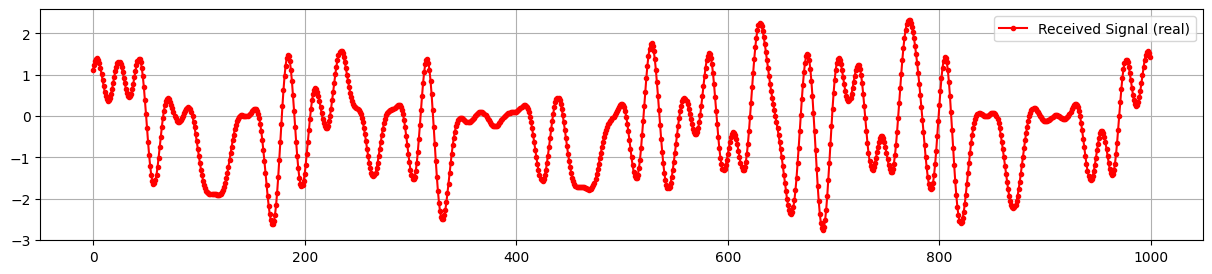

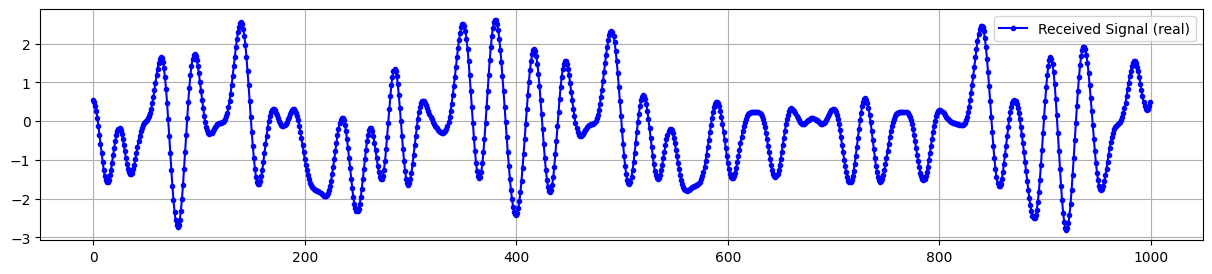

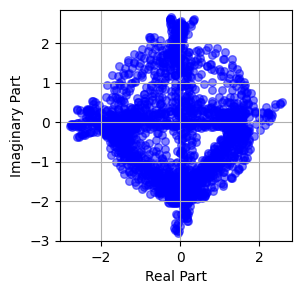

In [31]:
Ts = 1/fs # calc sample period
t = np.arange(0, Ts*len(normalized_rx), Ts) # create time vector
coarse_corrected = normalized_rx * np.exp(-1j*2*np.pi*max_freq*t/4.0)


plot_signal(coarse_corrected.real, 1000, 'Received Signal (real)', 'red') 
plot_signal(coarse_corrected.imag, 1000, 'Received Signal (real)', 'blue')
plot_scatter(coarse_corrected[:2000])

## Normalization 2 (Increase Signal Amplitude)
### Unit Power Normalization 

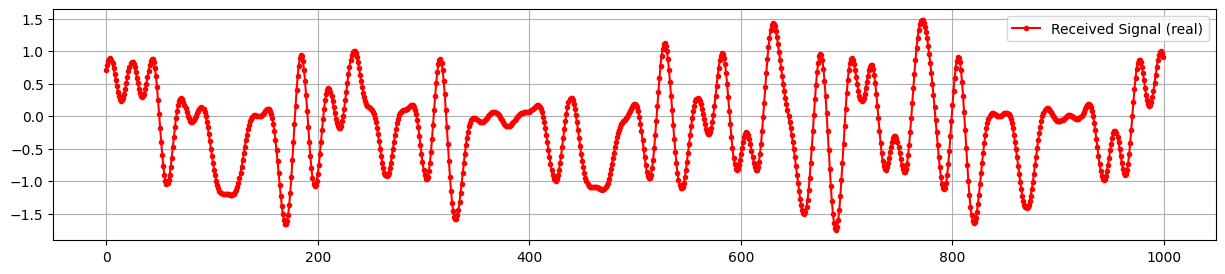

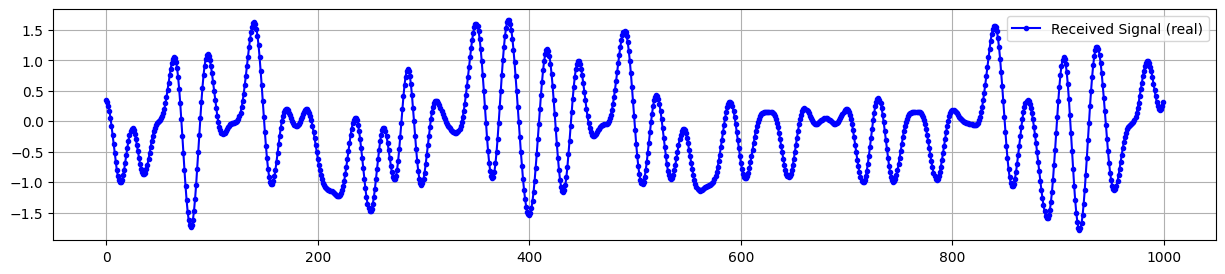

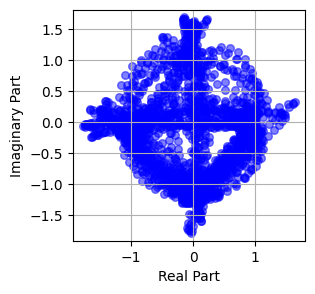

In [32]:
power = np.mean(np.abs(coarse_corrected)**2)
normalized_2 = coarse_corrected / np.sqrt(power)

plot_signal(normalized_2.real, 1000, 'Received Signal (real)', 'red') 
plot_signal(normalized_2.imag, 1000, 'Received Signal (real)', 'blue')
plot_scatter(normalized_2[:2000])

# NEW 
## ( Time Sync Comes before Fine Frequecy Sync)

## Time Synchronization

### Mueller and Muller clock recovery technique

time sync time 0.26328229904174805


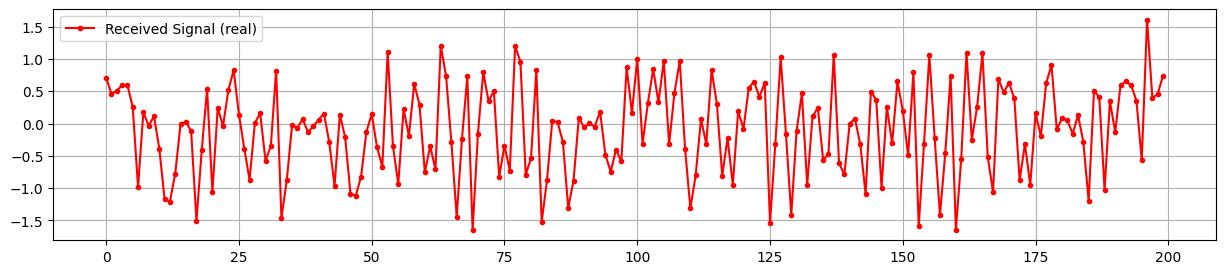

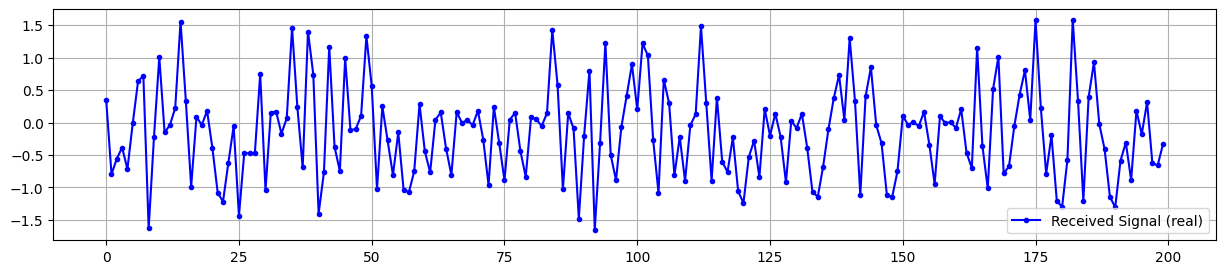

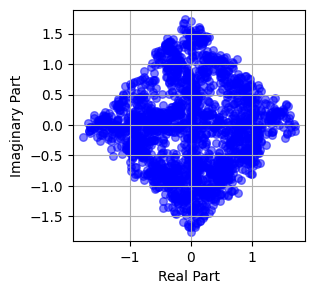

In [33]:
import time
t_start = time.time()

###############################################################
samples  = normalized_2
# samples_interpolated = signal.resample_poly(samples, 16, 1)
mu = 0 
out = np.zeros(len(samples) + 10, dtype=np.complex64)
out_rail = np.zeros(len(samples) + 10, dtype=np.complex64) #
i_in = 0 
i_out = 2 
while i_out < len(samples) and i_in+16 < len(samples):
    # out[i_out] = samples_interpolated[i_in*16 + int(mu*16)]
    out[i_out] = samples[i_in]
    out_rail[i_out] = int(np.real(out[i_out]) > 0) + 1j*int(np.imag(out[i_out]) > 0)
    x = (out_rail[i_out] - out_rail[i_out-2]) * np.conj(out[i_out-1])
    y = (out[i_out] - out[i_out-2]) * np.conj(out_rail[i_out-1])
    mm_val = np.real(y - x)
    mu += sps + 0.3*mm_val
    i_in += int(np.floor(mu))
    mu = mu - np.floor(mu) 
    i_out += 1 
out = out[2:i_out] 
time_sync = out
#########################################################################
# from numba import njit
# @njit
# def mm_timing_recovery(samples_interpolated, sps):
#     mu = 0.0
#     out = np.zeros(len(samples_interpolated)//16 + 10, dtype=np.complex64)
#     out_rail = np.zeros_like(out)
#     i_in = 0
#     i_out = 2
#     while i_out < len(out) and i_in + 16 < len(samples_interpolated)//16:
#         out[i_out] = samples_interpolated[i_in*16 + int(mu*16)]
#         out_rail[i_out] = complex(
#             int(np.real(out[i_out]) > 0),
#             int(np.imag(out[i_out]) > 0)
#         )
#         x = (out_rail[i_out] - out_rail[i_out-2]) * np.conj(out[i_out-1])
#         y = (out[i_out] - out[i_out-2]) * np.conj(out_rail[i_out-1])
#         mm_val = np.real(y - x)
#         mu += sps + 0.3 * mm_val
#         i_in += int(np.floor(mu))
#         mu -= np.floor(mu)
#         i_out += 1
#     return out[2:i_out]

# import time
# t0 = time.time()
# samples_interpolated = signal.resample_poly(normalized_2, 16, 1)
# print("Resample time:", time.time() - t0)

# t1 = time.time()
# time_sync = mm_timing_recovery(samples_interpolated, sps=10)
# print("Timing recovery time:", time.time() - t1)


print('time sync time', time.time() - t_start)

plot_signal(time_sync.real, 200, 'Received Signal (real)', 'red') 
plot_signal(time_sync.imag, 200, 'Received Signal (real)', 'blue')
plot_scatter(time_sync[:2000])

# NEW
## Error function in Coastas Loop is updated
```error = phase_detector_4(fine_correct[i])```

## Fine Frequency Synchronization
### Costas Loop

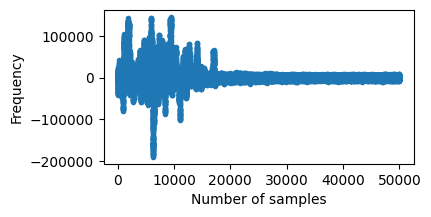

In [34]:
def phase_detector_4(sample):
    if sample.real > 0:
        a = 1.0
    else:
        a = -1.0
    if sample.imag > 0:
        b = 1.0
    else:
        b = -1.0
    return a * sample.imag - b * sample.real
    
samples = time_sync
N = len(samples)
phase = 0
freq = 0
# alpha = 0.132
# beta = 0.00932

alpha = 0.102
beta = 0.00532
fine_correct = np.zeros(N, dtype=np.complex64)
freq_log = []
for i in range(N):
    fine_correct[i] = samples[i] * np.exp(-1j*phase)
    error = phase_detector_4(fine_correct[i])
    freq += (beta * error)
    freq_log.append(freq * fs / (2*np.pi)) 
    phase += freq + (alpha * error)
    while phase >= 2*np.pi:
        phase -= 2*np.pi
    while phase < 0:
        phase += 2*np.pi

plt.figure(figsize=(4, 2))
plt.plot(freq_log,'.-')
plt.xlabel('Number of samples')
plt.ylabel('Frequency')
plt.show()

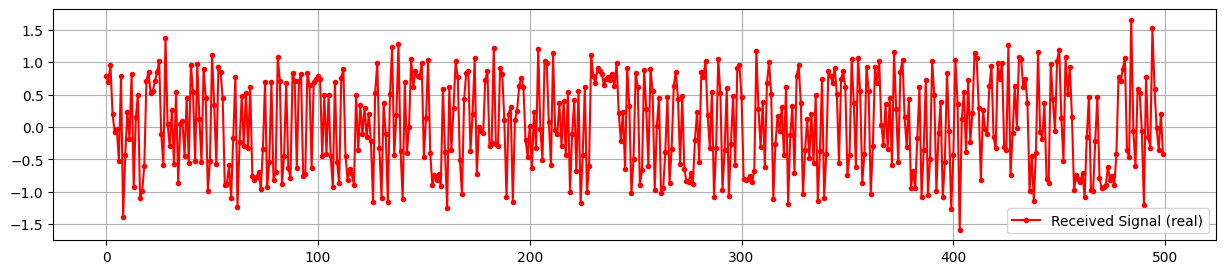

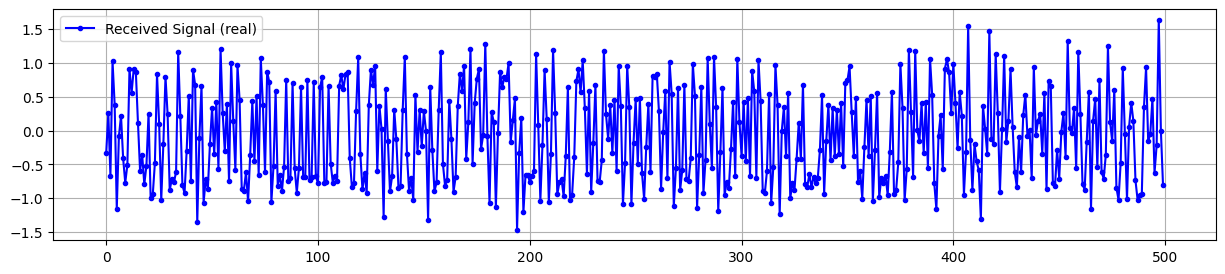

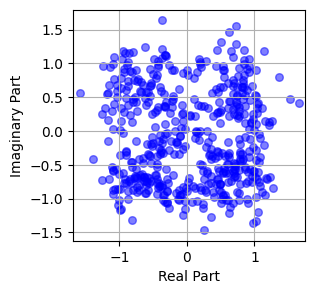

In [35]:
plot_signal(fine_correct.real[200:], 500, 'Received Signal (real)', 'red') 
plot_signal(fine_correct.imag[200:], 500, 'Received Signal (real)', 'blue')
plot_scatter(fine_correct[200:200+500])

# Frame Synchronization - Barker

In [36]:
barker_code = np.array([1+1j, 1+1j, 1+1j, 1+1j, 1+1j, -1-1j, -1-1j, 
1+1j, 1+1j, -1-1j, 1+1j, -1-1j, 1+1j])
barker_correlated = np.correlate(fine_correct, barker_code, mode='full')
offset_temp  = np.argmax(np.abs(barker_correlated))+1
if (len(fine_correct) - offset_temp) > 12004: 
    offset = offset_temp
else:
    corr_abs = np.abs(barker_correlated)
    first_idx = np.argmax(corr_abs)
    corr_abs[first_idx] = -np.inf
    second_idx = np.argmax(corr_abs)
    offset = second_idx + 1
peak = (barker_correlated)[offset-1]
print('peak:', np.round(peak, 3))

peak: (18.586-0.478j)


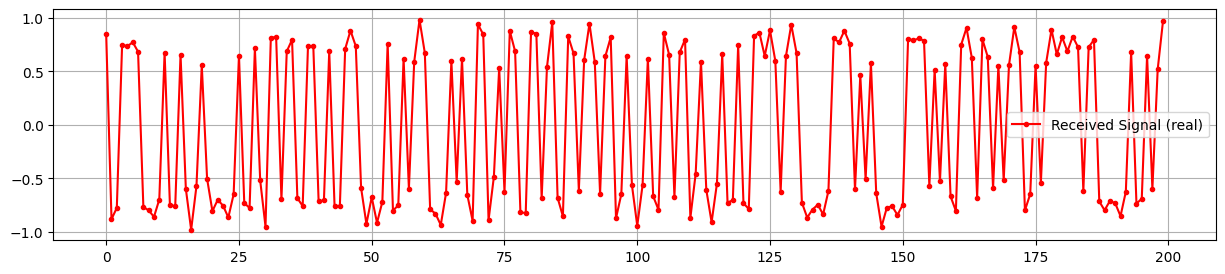

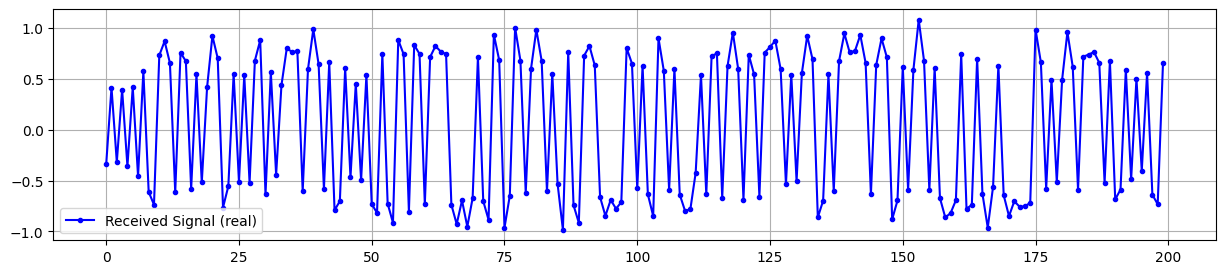

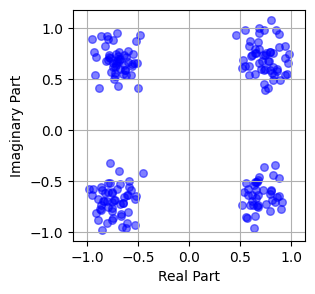

In [37]:
# n_bits = 140
plot_signal(fine_correct.real[offset:offset+200], 500, 'Received Signal (real)', 'red') 
plot_signal(fine_correct.imag[offset:offset+200], 500, 'Received Signal (real)', 'blue')
plot_scatter(fine_correct[offset:offset+200])

# NEW


## Phase -Rotation Correction

### In BPSK we did this by

```
if peak < 0:
    time_sync = -1*time_sync
```

### For QAM

In [38]:
n_bits = int(20008/2)  # Number of message bits
fr_sync_op = fine_correct[offset:offset+n_bits]

phase_rad = np.angle(peak)
phase_corrected = fr_sync_op * np.exp(1j * -phase_rad)


# NEW

## 4-QAM Demodulation

In [39]:
recovered_bits_real = (phase_corrected.real > 0).astype(int)
recovered_bits_img = (phase_corrected.imag > 0).astype(int)
combined_bits = np.column_stack((recovered_bits_real, recovered_bits_img)).reshape(-1)
print(combined_bits, len(combined_bits))

[1 0 0 ... 0 1 1] 20008


In [40]:
import binascii
def verify_crc(received_frame):
    received_payload = received_frame[:-16]
    received_crc = received_frame[-16:]
    byte_data = np.packbits(received_payload)  
    crc = binascii.crc_hqx(byte_data, 0xFFFF)  
    expected_crc = np.array(list(np.binary_repr(crc, width=16)), dtype=np.uint8)  
    if np.array_equal(received_crc, expected_crc):
        return True  
    else:
        return False 

verify_crc(combined_bits)

True

# Source Decoding

### Binary to ASCII, ASCII to text

In [41]:
def bin_to_text(binary_arr):
    bin_str = "".join(str(bit) for bit in binary_arr)
    text = ""
    for i in range(0, len(bin_str), 7):
        byte = bin_str[i:i+7]
        if len(byte) == 7 :
          text += chr(int(byte, 2))
    return text

decoded_text = bin_to_text(combined_bits[:-16])
print('Decoded text:', decoded_text)

Decoded text: In the digital age, privacy has become one of the most debated and critical issues. With every click, swipe, and search, individuals leave behind a trail of data. This data, often collected without explicit consent, is used by corporations, advertisers, and sometimes even governments. While digital tools offer convenience and personalization, they also raise concerns about surveillance, data breaches, and identity theft. People are increasingly aware of how their personal information is being tracked, stored, and monetized. As a result, calls for stronger privacy regulations, ethical data practices, and transparent technology use are gaining momentum around the world, prompting urgent discussions.

Digital privacy has become a defining concern of the 21st century, shaping the way individuals, businesses, and governments interact online. As our dependence on digital technologies grows, so does the amount of data we generate-often unknowingly. From smartphones and smartwatc

In [42]:
text_message = '''In the digital age, privacy has become one of the most debated and critical issues. With every click, swipe, and search, individuals leave behind a trail of data. This data, often collected without explicit consent, is used by corporations, advertisers, and sometimes even governments. While digital tools offer convenience and personalization, they also raise concerns about surveillance, data breaches, and identity theft. People are increasingly aware of how their personal information is being tracked, stored, and monetized. As a result, calls for stronger privacy regulations, ethical data practices, and transparent technology use are gaining momentum around the world, prompting urgent discussions.

Digital privacy has become a defining concern of the 21st century, shaping the way individuals, businesses, and governments interact online. As our dependence on digital technologies grows, so does the amount of data we generate-often unknowingly. From smartphones and smartwatches to social media platforms and online banking, our digital footprint expands with every interaction, posing significant challenges to personal privacy and data security.

The convenience of digital services comes at a price. Search engines track our queries, social media apps monitor our behaviors, and e-commerce websites analyze our shopping habits. While this data collection helps companies offer personalized experiences and targeted advertising, it often occurs without clear user consent or understanding. The question arises: how much privacy are we sacrificing for convenience?

Data breaches have become alarmingly common. High-profile incidents involving companies like Equifax, Facebook, and Marriott have exposed millions of users’ personal information, including names, addresses, passwords, and even financial details. These breaches not only compromise user security but also erode trust in digital platforms. Once private data is leaked, it can be exploited by cybercriminals for identity theft, financial fraud, or blackmail.

Governments are also involved in digital surveillance, often citing national security concerns. Programs like PRISM, revealed by Edward Snowden in 2013, demonstrated how intelligence agencies could access data from major tech companies without users’ knowledge. While some argue this surveillance helps prevent crime and terrorism, critics warn it threatens civil liberties and the right to privacy. In authoritarian regimes, surveillance tools are sometimes used to monitor political opponents, journalists, and activists.

In response to these concerns, countries have started implementing stronger data protection laws. The European Union’s General Data Protection Regulation (GDPR), enacted in 2018, is one of the most comprehensive frameworks. It gives individuals greater control over their data, requires.....

'''

In [43]:
def text_to_bin(text):
    temp_bin_str = ''.join(format(ord(c), '07b') for c in text)
    bin_data = np.array([int(bit) for bit in temp_bin_str], dtype=int)
    return bin_data

message_bits = text_to_bin(text_message)
print(len(message_bits))

original_bits = message_bits
received_bits = combined_bits[:-16]
print(len(message_bits), len(received_bits))

# --- Step 2: Compute bit errors ---
bit_errors = np.sum(original_bits != received_bits)
ber = bit_errors / len(original_bits)

# --- Step 3: Display results ---
print(f"Total bits compared: {len(original_bits)}")
print(f"Bit errors: {bit_errors}")
print(f"Bit Error Rate (BER): {ber:.6f}")

19992
19992 19992
Total bits compared: 19992
Bit errors: 0
Bit Error Rate (BER): 0.000000


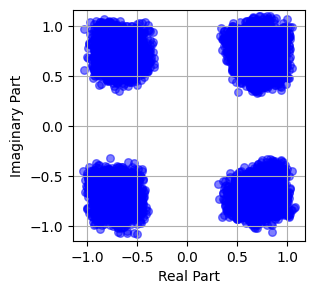

In [44]:
plot_scatter(fine_correct[offset:offset+n_bits])